In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import joblib
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
from scipy.interpolate import interp1d

In [63]:
file_path = 'data.csv'
data = pd.read_csv(file_path)
print("Dataset Information")
data.info()
print("\nFirst 5 Rows of the Dataset")
print(data.head())



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perime

In [64]:
data = data.drop(columns=['id', 'Unnamed: 32'])
data['diagnosis'] = LabelEncoder().fit_transform(data['diagnosis'])
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [65]:
def tune_and_evaluate_model(model, param_grid):
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    print(f"\n{type(best_model).__name__} Model Results:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Best Parameters:", grid_search.best_params_)
    return best_model

In [66]:
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Model Results:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Training Random Forest Classifier...

Random Forest Model Results:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Accuracy: 0.9649122807017544


In [67]:
print("\nTuning Random Forest Classifier...")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_model = tune_and_evaluate_model(RandomForestClassifier(random_state=42), rf_param_grid)



Tuning Random Forest Classifier...

RandomForestClassifier Model Results:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Accuracy: 0.9649122807017544
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [68]:
# Train and evaluate Gradient Boosting
print("\nTraining Gradient Boosting Classifier...")
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print("\nGradient Boosting Model Results:")
print(classification_report(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))


Training Gradient Boosting Classifier...

Gradient Boosting Model Results:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy: 0.956140350877193


In [69]:
# Re-initialize models with slightly tuned hyperparameters for better generalization
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [70]:
# Plot ROC Curve
def plot_roc_curve(model, model_name, X_test, y_test):
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    unique_fpr, unique_indices = np.unique(fpr, return_index=True)
    unique_tpr = tpr[unique_indices]
    fpr_smooth = np.linspace(0, 1, 100)
    try:
        tpr_smooth = interp1d(unique_fpr, unique_tpr, kind='quadratic', fill_value="extrapolate")(fpr_smooth)
    except ValueError:
        tpr_smooth = interp1d(unique_fpr, unique_tpr, kind='linear')(fpr_smooth)
    plt.plot(fpr_smooth, tpr_smooth, label=f'{model_name} (AUC = {roc_auc:.2f})')

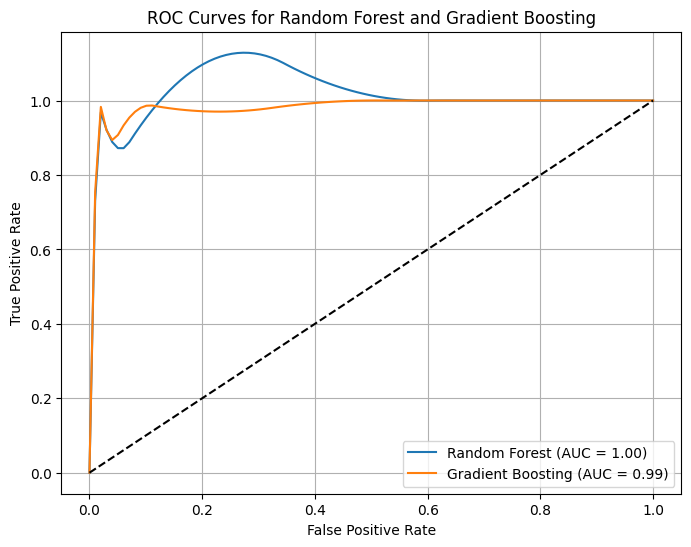

In [71]:
plt.figure(figsize=(8, 6))
plot_roc_curve(rf_model, "Random Forest", X_test, y_test)
plot_roc_curve(gb_model, "Gradient Boosting", X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Random Forest and Gradient Boosting")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [73]:
# ✅ Save trained models and scaler as joblib files
joblib.dump(rf_model, "random_forest_model.joblib")
joblib.dump(gb_model, "gradient_boosting_model.joblib")
joblib.dump(scaler, "scaler.joblib")

print("\n✅ Models and Scaler saved successfully as joblib files.")


✅ Models and Scaler saved successfully as joblib files.
